In [3]:
!pip install torch==2.6

In [4]:
from pathlib import Path

from lightning import pytorch as pl
from lightning.pytorch.callbacks import ModelCheckpoint
import pandas as pd

from chemprop import data, featurizers, models, nn

In [5]:
from tdc.single_pred import ADME 

#ADME(...) builds an ADME object - with name= telling which datset (keyword argument) input passed by its label rather than position
#'.' means reach inside the thing on my left and use one of its built-in abilities (a method)
#.get_split(...) runs the ADME machine's "split the data" ability. seed=42 lets the previous GNN use the same partition without sharing any files 
#even scaffold split has a random step, once molecules are grouped by scaffold, the groups get shuffled before being delt into train/valid/test

split = ADME(name='Solubility_AqSolDB').get_split(method='scaffold', seed=42)

def make_datapoints(df): # (df) says function needs one input to do its job, and df is a placeholder. 
    smis = df['Drug'].values # df['Drug'] reaches into teh table and pulls out column - the SMILES string
                             #.values strips off the pandas table wrapping (row numbers, labels, etc)
                             #smis = ... stores the sequence under the name smis


    ys   = df[['Y']].values  # Single bracket would give one dimensional list of numbers, souble gives two dimenstional 
                             # Shape [N,1] - a grid, not a line. chemprop wants in this way it is build to predict multiple targets at one
    

    #Each loop, zip hands over a pair, and Python splits it open and drops the first thing into smi and the second into y
    return [data.MoleculeDatapoint.from_smi(smi, y) for smi, y in zip(smis, ys)] 
    # return: when function finishes.
    #outer square bracket [...] builds a list comprehensiton - constructing a list by looping, 1 entry per trip through loop
    # zip(smis,ys) pairs the two sequences together element by element. Zip produced (SMILES,target)
    #'for smi, y in zip(smis, ys)' the loop: takes the next pair and unpacks it innto two names smi (one SMILES string) and y (that molecule's target, shape [1])

train_dp = make_datapoints(split['train'])
val_dp   = make_datapoints(split['valid'])
test_dp  = make_datapoints(split['test'])

print(len(train_dp), len(val_dp), len(test_dp))
print(train_dp[0])

#Turned three tables of (SMILES,solubility) into three lists of Chemprop MoleculeDatapoint objects - each molecule parsed from text into real chemical structure

Found local copy...
Loading...
Done!
 40%|███▉      | 3951/9982 [00:00<00:00, 7752.19it/s] CC1=CC=C[NH+2]([O-])[CH-]1 returns RDKit error and is thus omitted...
O=C(O)C1=C[NH+2]([O-])[CH-]C=C1 returns RDKit error and is thus omitted...
100%|██████████| 9982/9982 [00:01<00:00, 9570.28it/s] 


6986 998 1996
MoleculeDatapoint(mol=<rdkit.Chem.rdchem.Mol object at 0x7f7642a15310>, y=array([-2.17707794]), weight=1.0, gt_mask=None, lt_mask=None, x_d=None, x_phase=None, name='O=Cc1ccc(Cl)cc1', V_f=None, E_f=None, V_d=None)


In [6]:
#Aim of this cell 
# --- 1 ---
      #Build the featuriser - featurizers.SimpleMoleculeMolGraphFeaturizer() 
      #Turns each stored RDKit mol into graph tensors - atom and bond features
      #Chemprops richer version compared to the featuriser in other notebook 
# --- 2 ---
      #Wrap each datapoint list in a MoleculeDataset.
      #Pairs list of datapoints with the featurizer.
      #Doesn't featurize immediately, holsd the recipe and featurizes each molecule on demand when the dataloader asks
# --- 3 ---  
      #Fir a target scaler

from chemprop import data, featurizers

featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer() 

train_dset = data.MoleculeDataset(train_dp, featurizer)
val_dset = data.MoleculeDataset(val_dp, featurizer)
test_dset = data.MoleculeDataset(test_dp, featurizer)

scaler = train_dset.normalize_targets() #Apply the same scaler to val to prevent any data leakage that would come if mean and std of val was calculated for its own normalisation
val_dset.normalize_targets(scaler) # the scaler carries the mean and std of train hence it is inputted to normalize the v_dset

print(scaler.mean_,scaler.scale_)

[-2.58109003] [2.26705901]


In [7]:
#The dataloader, takes dataset and serves it to the model in batches. 
#important to shuffle train so the model doesn't see any patterns and learn somthing from the ordering

train_loader = data.build_dataloader(train_dset, shuffle = True)
val_loader = data.build_dataloader(val_dset, shuffle = False)
test_loader = data.build_dataloader(test_dset, shuffle = False)



In [8]:
#Building the D-MPNN, diverging from the GCN. same skeleton: message passing -> readou -> prediction head

from chemprop import nn 
from chemprop import models

#Message passing - the "atoms gather from neighbours" stage
mp = nn.BondMessagePassing()

#aggregation - the readour, "collapse atomss into one molecule vector"

agg = nn.MeanAggregation()

#The head, with unscaling built in
#Earlier the targets where standardized, the scalar was used, so the model is trained to predict standardized numbers, not real logS
#Hence need to reverse this standardization
output_transform = nn.UnscaleTransform.from_standard_scaler(scaler) #Builds the reverse

#Builds the prediction head and bolts the reversal into it.
#nn.RegressionFFN(...) is the feed-forward head (300 numbers -> 1)
#Passing output_transform=output_transform tells it; after you compute your raw standarized output, run it through this un-scaler before handing it back
#So the head now does two steps internally - predicts a z-score, then unscales it - and its final output is in real logS units
ffn = nn.RegressionFFN(output_transform=output_transform)

batch_norm = True #stabilizer switch, this is just setting a flag to be handed to the model on the last line
#It doesn't build anything itself . True means "yes, include a batch-normalization layer." useful default.

metric_list = [nn.metrics.RMSE(), nn.metrics.MAE()] # How the model is scored, 

mpnn = models.MPNN(mp, agg, ffn, batch_norm, metric_list)
mpnn

MPNN(
  (message_passing): BondMessagePassing(
    (W_i): Linear(in_features=86, out_features=300, bias=False)
    (W_h): Linear(in_features=300, out_features=300, bias=False)
    (W_o): Linear(in_features=372, out_features=300, bias=True)
    (dropout): Dropout(p=0.0, inplace=False)
    (tau): ReLU()
    (V_d_transform): Identity()
    (graph_transform): Identity()
  )
  (agg): MeanAggregation()
  (bn): BatchNorm1d(300, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (predictor): RegressionFFN(
    (ffn): MLP(
      (0): Sequential(
        (0): Linear(in_features=300, out_features=300, bias=True)
      )
      (1): Sequential(
        (0): ReLU()
        (1): Dropout(p=0.0, inplace=False)
        (2): Linear(in_features=300, out_features=1, bias=True)
      )
    )
    (criterion): MSE(task_weights=[[1.0]])
    (output_transform): UnscaleTransform()
  )
  (X_d_transform): Identity()
  (metrics): ModuleList(
    (0): RMSE(task_weights=[[1.0]])
    (1): MAE(task_weigh

In [9]:
#The trainer

from lightning import pytorch as pl 
from lightning.pytorch.callbacks import ModelCheckpoint

checkpointing = ModelCheckpoint(
    dirpath="checkpoints",
    filename="best-{epoch}-{val_loss:.2f}",
    monitor="val_loss",
    mode="min",
    save_last=True,
)

trainer=pl.Trainer(
    logger=False, #Skip experiment-logging frameworks; not needed for one model 
    enable_checkpointing=True,
    enable_progress_bar=True,
    accelerator="cuda",
    devices=1,
    max_epochs=20,
    callbacks=[checkpointing]
)



GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [10]:
trainer.fit(mpnn, train_loader, val_loader)

You are using a CUDA device ('NVIDIA GeForce RTX 3060') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  227 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    600 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 90.6 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 318 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 318 K                                                                                                
Total estimated model params size (MB): 1.276                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=20` reached.


In [12]:
results = trainer.test(mpnn, test_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.8295321464538574     │
│         test/rmse         │    1.1476585865020752     │
└───────────────────────────┴───────────────────────────┘

In [16]:
import matplotlib.pyplot as plt
import numpy as np
preds  = trainer.predict(mpnn, test_loader)
y_pred = np.concatenate([p.numpy() for p in preds]).ravel()      # predicted logS (already unscaled)
y_true = np.array([dp.y[0] for dp in test_dp])                    # true logS

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

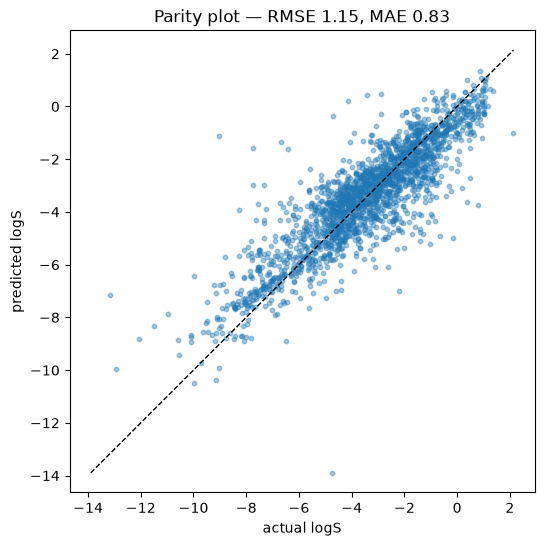

In [17]:
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, s=10, alpha=0.4)
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, 'k--', lw=1)                    # the y=x ideal
plt.xlabel("actual logS"); plt.ylabel("predicted logS")
plt.title(f"Parity plot — RMSE {1.15:.2f}, MAE {0.83:.2f}")
plt.axis('equal'); plt.show()

In [19]:
from lightning import pytorch as pl
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from chemprop import nn, models

# --- rebuild the model FRESH so weights start from random (not continuing the old run) ---
mp  = nn.BondMessagePassing()
agg = nn.MeanAggregation()
output_transform = nn.UnscaleTransform.from_standard_scaler(scaler)
ffn = nn.RegressionFFN(output_transform=output_transform)
batch_norm  = True
metric_list = [nn.metrics.RMSE(), nn.metrics.MAE()]
mpnn = models.MPNN(mp, agg, ffn, batch_norm, metric_list)

# --- checkpoint on best val loss ---
checkpointing = ModelCheckpoint(
    dirpath="checkpoints",
    filename="best-{epoch}-{val_loss:.2f}",
    monitor="val_loss",
    mode="min",
    save_last=True,
)

# --- trainer with CSV logging on, 40 epochs ---
trainer = pl.Trainer(
    logger=CSVLogger("logs", name="chemprop_solubility"),
    enable_checkpointing=True,
    enable_progress_bar=True,
    accelerator="cuda",     
    devices=1,
    max_epochs=40,
    callbacks=[checkpointing],
)

# --- train, then test ---
trainer.fit(mpnn, train_loader, val_loader)
results = trainer.test(mpnn, test_loader)

# --- find the metrics CSV and show its columns so we can plot next ---
import pandas as pd, glob, os
csv_path = sorted(glob.glob("logs/chemprop_solubility/version_*/metrics.csv"), key=os.path.getmtime)[-1]
m = pd.read_csv(csv_path)
print("\nmetrics CSV:", csv_path)
print("columns:", m.columns.tolist())

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  227 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    600 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 90.6 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 318 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 318 K                                                                                                
Total estimated model params size (MB): 1.276                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=40` reached.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.8468785285949707     │
│         test/rmse         │     1.189412236213684     │
└───────────────────────────┴───────────────────────────┘


metrics CSV: logs/chemprop_solubility/version_0/metrics.csv
columns: ['epoch', 'step', 'test/mae', 'test/rmse', 'train_loss_epoch', 'train_loss_step', 'val/mae', 'val/rmse', 'val_loss']


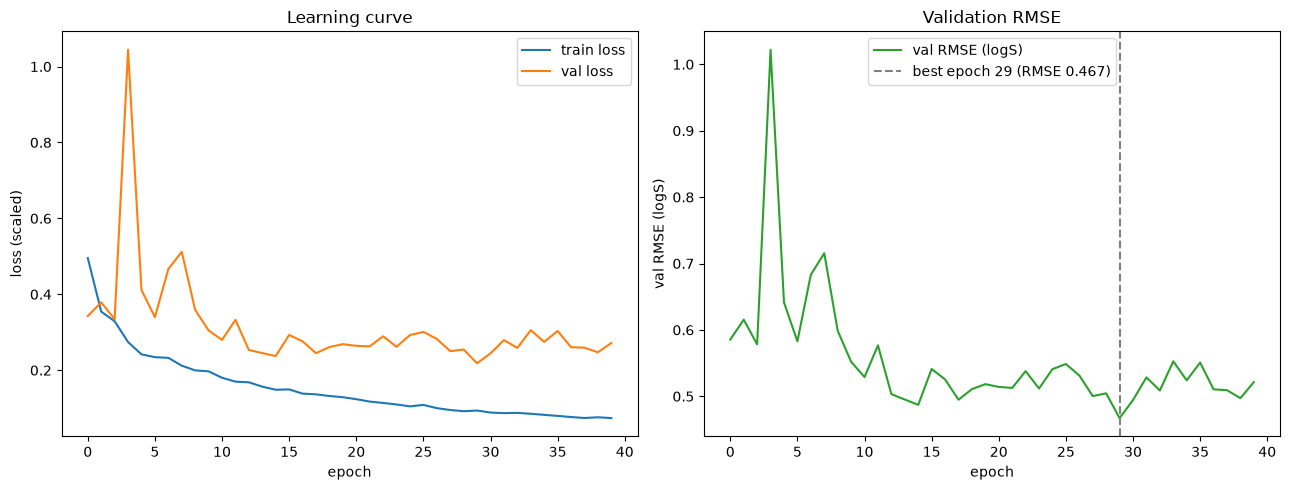

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

m = pd.read_csv("logs/chemprop_solubility/version_0/metrics.csv")

# collapse the separate train/val rows into one value per epoch
train_loss = m.groupby("epoch")["train_loss_epoch"].mean().dropna()
val_loss   = m.groupby("epoch")["val_loss"].mean().dropna()
val_rmse   = m.groupby("epoch")["val/rmse"].mean().dropna()   # in real logS units

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# --- left: the learning curve (scaled loss) ---
ax[0].plot(train_loss.index, train_loss.values, label="train loss")
ax[0].plot(val_loss.index,   val_loss.values,   label="val loss")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss (scaled)")
ax[0].set_title("Learning curve"); ax[0].legend()

# --- right: validation RMSE in real units, with the best epoch marked ---
best_epoch = val_rmse.idxmin()
ax[1].plot(val_rmse.index, val_rmse.values, color="tab:green", label="val RMSE (logS)")
ax[1].axvline(best_epoch, ls="--", color="grey",
              label=f"best epoch {best_epoch} (RMSE {val_rmse.min():.3f})")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("val RMSE (logS)")
ax[1].set_title("Validation RMSE"); ax[1].legend()

plt.tight_layout(); plt.show()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

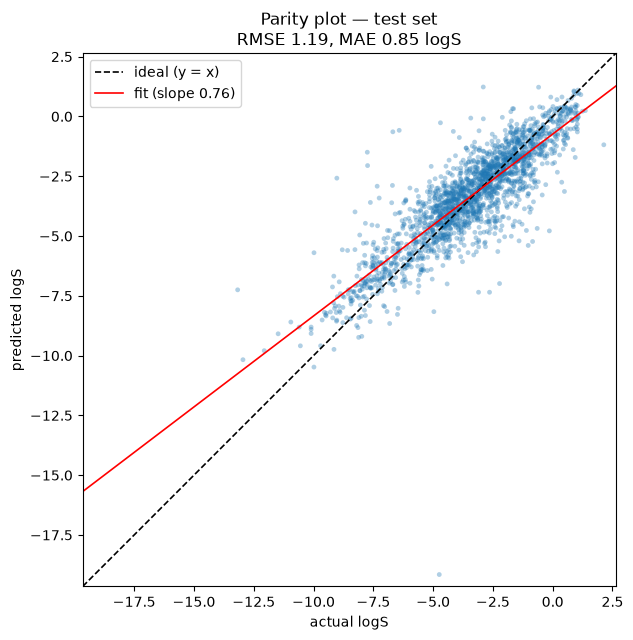

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# --- get test predictions (already unscaled to real logS by the model's output_transform) ---
preds  = trainer.predict(mpnn, test_loader)
y_pred = np.concatenate([p.numpy() for p in preds]).ravel()
y_true = np.array([dp.y[0] for dp in test_dp])

# --- parity plot ---
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(y_true, y_pred, s=12, alpha=0.35, edgecolor="none")

# ideal y = x line
lims = [min(y_true.min(), y_pred.min()) - 0.5, max(y_true.max(), y_pred.max()) + 0.5]
ax.plot(lims, lims, "k--", lw=1.2, label="ideal (y = x)")

# fitted trend line through the predictions — reveals systematic tilt
slope, intercept = np.polyfit(y_true, y_pred, 1)
xs = np.array(lims)
ax.plot(xs, slope * xs + intercept, "r-", lw=1.2,
        label=f"fit (slope {slope:.2f})")

rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
mae  = np.mean(np.abs(y_pred - y_true))
ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")
ax.set_xlabel("actual logS"); ax.set_ylabel("predicted logS")
ax.set_title(f"Parity plot — test set\nRMSE {rmse:.2f}, MAE {mae:.2f} logS")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()